Prototype for face recognition system

In [23]:
from google.colab import files
uploaded = files.upload()



Saving handsome-man-smiling-happy-face-portrait-close-up.jpg to handsome-man-smiling-happy-face-portrait-close-up (2).jpg


In [16]:
import os
import cv2
import numpy as np
from sklearn.datasets import fetch_olivetti_faces

print("Downloading the dataset... (This might take a few seconds)")
# This downloads the AT&T ORL dataset
data = fetch_olivetti_faces()
images = data.images
labels = data.target

# Create our main 'dataset' folder
base_dir = "dataset"
os.makedirs(base_dir, exist_ok=True)

print("Structuring the folders...")
for i, (img, label) in enumerate(zip(images, labels)):
    # Create a subfolder for each specific person (Person_00 to Person_39)
    person_dir = os.path.join(base_dir, f"Person_{label:02d}")
    os.makedirs(person_dir, exist_ok=True)

    # The dataset provides images in a 0.0 to 1.0 format.
    # We need to convert them to standard 0 to 255 pixel values for OpenCV.
    img_cv = (img * 255).astype(np.uint8)

    # Save the image into the correct folder
    img_path = os.path.join(person_dir, f"image_{i:03d}.jpg")
    cv2.imwrite(img_path, img_cv)

print(f"Dataset is ready! We successfully saved {len(images)} images across {len(np.unique(labels))} different folders.")

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data
Structuring the folders...
Dataset is ready! We successfully saved 400 images across 40 different folders.


In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris

# Load data
data = load_iris()
X, y = data.data, data.target

# Initialize and fit PCA
# We've chosen 2 components so we can plot it on a 2D graph
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")

# Visualization
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA of Iris Dataset')
plt.show()

Feature,PCA,LDA
Type,Unsupervised,Supervised
Focus,Capturing maximum variance,Maximizing class separability
Requirement,Only features (X),Features (X) and Labels (y)
Use Case,Data compression / Visualization,Feature extraction for classification

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

# Initialize and fit LDA
# Note: LDA requires 'y' (labels) during the fit process
lda = LDA(n_components=2)
X_lda = lda.fit_transform(X, y)

# Visualization
plt.scatter(X_lda[:, 0], X_lda[:, 1], c=y, cmap='plasma')
plt.xlabel('LD1')
plt.ylabel('LD2')
plt.title('LDA of Iris Dataset')
plt.show()

In [ ]:
import cv2
from google.colab.patches import cv2_imshow

# Load the image in color (BGR format)
img = cv2.imread('handsome-man-smiling-happy-face-portrait-close-up.jpg')

# Convert to grayscale
# COLOR_BGR2GRAY is used because OpenCV loads images in BGR order by default
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Save the result
cv2.imwrite('handsome-man-smiling-happy-face-portrait-close-up.jpg', gray_img)

# Display the images using the Colab patch
print('Original Image:')
cv2_imshow(img)
print('Grayscale Image:')
cv2_imshow(gray_img)

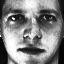

In [17]:
import cv2
from google.colab.patches import cv2_imshow

def preprocess_for_recognition(image_path):
    # Load image
    img = cv2.imread(image_path)

    # 1. Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 2. Normalize Illumination (Histogram Equalization)
    # This enhances contrast so the PCA model performs better
    normalized_gray = cv2.equalizeHist(gray)

    return normalized_gray

# Usage
processed_img = preprocess_for_recognition('dataset/Person_00/image_000.jpg')
# Use cv2_imshow instead of cv2.imshow
cv2_imshow(processed_img)

In [18]:
import cv2
import os
import numpy as np
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from google.colab.patches import cv2_imshow # Import cv2_imshow for Colab compatibility

# --- Configuration ---
TARGET_SIZE = (100, 100) # Standardized size for PCA/LDA
DATASET_PATH = "dataset" # Path to your downloaded face database
TEST_IMAGE_PATH = "dataset/Person_00/image_000.jpg"

# Load OpenCV's pre-trained Viola-Jones Haar Cascade for face detection
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

def detect_and_preprocess(image_path, apply_detection=True):
    """
    Reads an image, optionally detects faces, converts to grayscale,
    normalizes illumination, and resizes to a standard spatial size.
    """
    img = cv2.imread(image_path)
    if img is None:
        return None

    # 1. Convert color to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    if apply_detection:
        # 2. Face Detection (Viola & Jones)
        faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

        if len(faces) == 0:
            return None # No face detected

        # Take the largest face found in the image
        (x, y, w, h) = max(faces, key=lambda rect: rect[2] * rect[3])
        face_crop = gray[y:y+h, x:x+w]
    else:
        # Assume the image is already cropped to the face
        face_crop = gray

    # 3. Illumination Normalization (Histogram Equalization)
    face_eq = cv2.equalizeHist(face_crop)

    # 4. Spatial/Scale Normalization (Resize to fixed dimensions)
    face_resized = cv2.resize(face_eq, TARGET_SIZE)

    return face_resized

def load_and_prepare_dataset(dataset_dir):
    """Loads images from directory, preprocesses them, and prepares labels."""
    X = []
    y = []

    if not os.path.exists(dataset_dir):
        print(f"Warning: Dataset folder '{dataset_dir}' not found. Please create it to train the model.")
        return np.array([]), np.array([])

    for person_name in os.listdir(dataset_dir):
        person_dir = os.path.join(dataset_dir, person_name)
        if not os.path.isdir(person_dir):
            continue

        for img_name in os.listdir(person_dir):
            img_path = os.path.join(person_dir, img_name)

            # Extract and preprocess face
            processed_face = detect_and_preprocess(img_path, apply_detection=True)

            if processed_face is not None:
                # Flatten the 2D image array into a 1D feature vector for PCA
                X.append(processed_face.flatten())
                y.append(person_name)

    return np.array(X), np.array(y)

# ==========================================
# 1. TRAINING PHASE (PCA + SVM)
# ==========================================
'''print("Loading and preprocessing dataset...")
X, y_labels = load_and_prepare_dataset(DATASET_PATH)

if len(X) > 0:
    # Encode string labels (names) into integers
    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(y_labels)

    # Initialize PCA (Eigenfaces method).
    # n_components is the number of principal components to keep.
    print("Training PCA model...")
    n_components = min(50, len(X)) # Keep up to 50 components, or fewer if dataset is small
    pca = PCA(n_components=n_components, whiten=True)

    # Fit PCA and reduce dimensionality of training data
    X_pca = pca.fit_transform(X)

    # Train a classifier (Support Vector Machine) on the PCA-reduced features
    # Note: You could use LDA here instead by wrapping the PCA output, or replacing PCA.
    print("Training SVM Classifier...")
    classifier = SVC(kernel='rbf', class_weight='balanced', probability=True)
    classifier.fit(X_pca, y)
    print("Training complete!")
else:
    print("Skipping training. Please add images to the dataset folder to train the recognition model.")'''

print("Loading and preprocessing dataset...")
X, y_labels = load_and_prepare_dataset(DATASET_PATH)

if len(X) > 0:
    # Encode string labels (names) into integers
    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(y_labels)

    # Step A: Apply PCA to solve the Small Sample Size problem
    print("Training PCA model...")
    # Keep components equal to (Number of images - Number of classes)
    # For safety in this script, we'll just use a sensible max like 50
    n_components_pca = min(50, len(X) - len(np.unique(y)))
    if n_components_pca < 1: n_components_pca = 1 # Fallback

    pca = PCA(n_components=n_components_pca, whiten=True)
    X_pca = pca.fit_transform(X)

    # Step B: Apply LDA on the PCA output
    print("Training LDA model...")
    # LDA components max out at (Number of classes - 1)
    n_components_lda = min(len(np.unique(y)) - 1, X_pca.shape[1])
    if n_components_lda < 1: n_components_lda = 1 # Fallback

    lda = LDA(n_components=n_components_lda)
    X_pca_lda = lda.fit_transform(X_pca, y) # Notice we pass 'y' here!

    print("Training complete! Feature space created.")
else:
    print("Skipping training. Please add images to the dataset folder.")

# ==========================================
# 2. INFERENCE PHASE (Testing the uploaded image)
# ==========================================
print(f"\nProcessing test image: {TEST_IMAGE_PATH}")
test_img_bgr = cv2.imread(TEST_IMAGE_PATH)

if test_img_bgr is not None:
    test_gray = cv2.cvtColor(test_img_bgr, cv2.COLOR_BGR2GRAY)

    # Detect face in the test image
    faces = face_cascade.detectMultiScale(test_gray, scaleFactor=1.1, minNeighbors=5, minSize=(60,60))

    for (x, y, w, h) in faces:
        # Draw a rectangle around the detected face
        cv2.rectangle(test_img_bgr, (x, y), (x+w, y+h), (0, 255, 0), 2)

        '''if len(X) > 0:
            # Preprocess the detected crop
            face_crop = test_gray[y:y+h, x:x+w]
            face_eq = cv2.equalizeHist(face_crop)
            face_resized = cv2.resize(face_eq, TARGET_SIZE)

            # Flatten and reshape for prediction
            face_vector = face_resized.flatten().reshape(1, -1)

            # Transform through the trained PCA model
            face_pca = pca.transform(face_vector)

            # Predict identity
            prediction = classifier.predict(face_pca)
            confidence = np.max(classifier.predict_proba(face_pca))

            predicted_name = label_encoder.inverse_transform(prediction)[0]

            # Display the predicted name on the image
            text = f"{predicted_name} ({confidence*100:.1f}%)"
            cv2.putText(test_img_bgr, text, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
            print(f"Detected face at [{x}, {y}, {w}, {h}]. Recognized as: {predicted_name}")
        else:
            print(f"Detected face at [{x}, {y}, {w}, {h}]. (Recognition skipped due to empty dataset)")
'''
        if len(X) > 0:
                # Preprocess the detected crop
                face_crop = test_gray[y:y+h, x:x+w]
                face_eq = cv2.equalizeHist(face_crop)
                face_resized = cv2.resize(face_eq, TARGET_SIZE)

                # Flatten and reshape for prediction
                face_vector = face_resized.flatten().reshape(1, -1)

                # 1. Transform through PCA
                test_pca = pca.transform(face_vector)

                # 2. Transform through LDA
                test_lda = lda.transform(test_pca)

                # 3. Calculate Squared Euclidean Distance (SED)
                min_dist = float('inf')
                best_match_idx = -1

                for i, train_vector in enumerate(X_pca_lda):
                    # SED formula: Sum of squared differences
                    dist = np.sum((test_lda[0] - train_vector) ** 2)

                    if dist < min_dist:
                        min_dist = dist
                        best_match_idx = y[i]

                # 4. Thresholding (Optional but recommended)
                # If the distance is too high, it's an unknown person.
                # You will need to tune this threshold number based on your specific dataset!
                SED_THRESHOLD = 50.0

                if min_dist < SED_THRESHOLD:
                    predicted_name = label_encoder.inverse_transform([best_match_idx])[0]
                    text = f"{predicted_name} (Dist: {min_dist:.1f})"
                    color = (0, 255, 0) # Green for known
                else:
                    predicted_name = "Unknown"
                    text = f"Unknown (Dist: {min_dist:.1f})"
                    color = (0, 0, 255) # Red for unknown

                # Display the predicted name on the image
                cv2.putText(test_img_bgr, text, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
                print(f"Detected face at [{x}, {y}, {w}, {h}]. Recognized as: {predicted_name} with SED: {min_dist:.2f}")

    # Show the final result
    cv2_imshow(test_img_bgr)
    cv2.waitKey(0)
    cv2.destroyAllWindows()
else:
    print("Could not load the test image. Ensure the path is correct.")

Loading and preprocessing dataset...
Training PCA model...
Training LDA model...


/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_pca.py:586: RuntimeWarning: invalid value encountered in divide
  explained_variance_ = (S**2) / (n_samples - 1)


ValueError: Found array with 1 sample(s) (shape=(1, 1)) while a minimum of 2 is required by LinearDiscriminantAnalysis.

Booting the laptop webcamm (booting the computer permission for webcamm and seek the person in it)

In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

def take_photo(filename='photo.jpg', quality=0.8):
  js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      // Resize the output to fit the video element.
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      // Wait for Capture to be clicked.
      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
  display(js)
  data = eval_js('takePhoto({})'.format(quality))
  binary = b64decode(data.split(',')[1])
  with open(filename, 'wb') as f:
    f.write(binary)
  return filename

In [ ]:
from IPython.display import Image
try:
  filename = take_photo()
  print('Saved to {}'.format(filename))

  # Show the image which was just taken.
  display(Image(filename))
except Exception as err:
  # Errors will be thrown if the user does not have a webcam or if they do not
  # grant the page permission to access it.
  print(str(err))

In [ ]:
import cv2
import numpy as np

def normalize_face(image_path):
    # Load the image in grayscale (standard for facial preprocessing)
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    # 1. Histogram Equalization
    # This spreads out the intensity levels to improve contrast
    equalized = cv2.equalizeHist(img)

    # 2. Gamma Correction
    # gamma > 1.0 will darken the image; gamma < 1.0 will brighten it
    gamma = 1.2
    invGamma = 1.0 / gamma
    # Create a lookup table (LUT) for performance
    table = np.array([((i / 255.0) ** invGamma) * 255
                      for i in np.arange(0, 256)]).astype("uint8")
    gamma_corrected = cv2.LUT(equalized, table)

    return gamma_corrected

# Usage
# result = normalize_face('my_face.jpg')

1. Checking dataset...

2. Loading and preprocessing dataset...
3. Training PCA model...
4. Training LDA model...
Training complete! Feature space created.

5. Processing test image: dataset/Person_01/image_010.jpg
Result: Person_01 with SED: 0.00


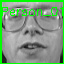

In [31]:
import cv2
import os
import numpy as np
from sklearn.datasets import fetch_olivetti_faces
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.preprocessing import LabelEncoder
from google.colab.patches import cv2_imshow

# ==========================================
# 0. SETUP AND DATASET DOWNLOAD
# ==========================================
TARGET_SIZE = (100, 100)
DATASET_PATH = "dataset"

print("1. Checking dataset...")
if not os.path.exists(DATASET_PATH) or len(os.listdir(DATASET_PATH)) < 2:
    print("Downloading the AT&T ORL Face Database...")
    data = fetch_olivetti_faces()
    os.makedirs(DATASET_PATH, exist_ok=True)
    for i, (img, label) in enumerate(zip(data.images, data.target)):
        person_dir = os.path.join(DATASET_PATH, f"Person_{label:02d}")
        os.makedirs(person_dir, exist_ok=True)
        img_cv = (img * 255).astype(np.uint8)
        cv2.imwrite(os.path.join(person_dir, f"image_{i:03d}.jpg"), img_cv)
    print("Dataset downloaded and structured successfully!")

# Testing the face image
TEST_IMAGE_PATH = "dataset/Person_01/image_010.jpg"

# Load Haar Cascade
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# ==========================================
# HELPER FUNCTIONS
# ==========================================
def detect_and_preprocess(image_path, apply_detection=True):
    img = cv2.imread(image_path)
    if img is None: return None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    if apply_detection:
        faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))
        if len(faces) == 0:
            face_crop = gray # Fallback: use whole image if already cropped
        else:
            (x, y, w, h) = max(faces, key=lambda rect: rect[2] * rect[3])
            face_crop = gray[y:y+h, x:x+w]
    else:
        face_crop = gray

    face_eq = cv2.equalizeHist(face_crop)
    face_resized = cv2.resize(face_eq, TARGET_SIZE)
    return face_resized

def load_and_prepare_dataset(dataset_dir):
    X, y = [], []
    for person_name in os.listdir(dataset_dir):
        person_dir = os.path.join(dataset_dir, person_name)
        if not os.path.isdir(person_dir): continue
        for img_name in os.listdir(person_dir):
            img_path = os.path.join(person_dir, img_name)
            processed_face = detect_and_preprocess(img_path, apply_detection=True)
            if processed_face is not None:
                X.append(processed_face.flatten())
                y.append(person_name)
    return np.array(X), np.array(y)

# ==========================================
# 1. TRAINING PHASE (PCA -> LDA)
# ==========================================
print("\n2. Loading and preprocessing dataset...")
X, y_labels = load_and_prepare_dataset(DATASET_PATH)

if len(X) < 2:
    raise ValueError("Not enough images to train! Please ensure the dataset downloaded correctly.")

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_labels)

print("3. Training PCA model...")
n_components_pca = min(50, len(X) - len(np.unique(y)))
if n_components_pca < 1: n_components_pca = 1
pca = PCA(n_components=n_components_pca, whiten=True)
X_pca = pca.fit_transform(X)

print("4. Training LDA model...")
n_components_lda = min(len(np.unique(y)) - 1, X_pca.shape[1])
if n_components_lda < 1: n_components_lda = 1
lda = LDA(n_components=n_components_lda)
X_pca_lda = lda.fit_transform(X_pca, y)

print("Training complete! Feature space created.")

# ==========================================
# 2. INFERENCE PHASE (SED)
# ==========================================
print(f"\n5. Processing test image: {TEST_IMAGE_PATH}")
test_img_bgr = cv2.imread(TEST_IMAGE_PATH)

if test_img_bgr is not None:
    test_gray = cv2.cvtColor(test_img_bgr, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(test_gray, scaleFactor=1.1, minNeighbors=5, minSize=(20,20))

    # Fallback for inference if no face detected
    if len(faces) == 0:
        faces = [(0, 0, test_gray.shape[1], test_gray.shape[0])]


    for (fx, fy, fw, fh) in faces:
        cv2.rectangle(test_img_bgr, (fx, fy), (fx+fw, fy+fh), (0, 255, 0), 2)

        face_crop = test_gray[fy:fy+fh, fx:fx+fw]
        face_eq = cv2.equalizeHist(face_crop)
        face_resized = cv2.resize(face_eq, TARGET_SIZE)
        face_vector = face_resized.flatten().reshape(1, -1)

        test_pca = pca.transform(face_vector)
        test_lda = lda.transform(test_pca)

        min_dist = float('inf')
        best_match_idx = -1

        for i, train_vector in enumerate(X_pca_lda):
            dist = np.sum((test_lda[0] - train_vector) ** 2)
            if dist < min_dist:
                min_dist = dist
                best_match_idx = y[i]

        SED_THRESHOLD = 50.0

        if min_dist < SED_THRESHOLD:
            predicted_name = label_encoder.inverse_transform([best_match_idx])[0]
            text = f"{predicted_name} (Dist: {min_dist:.1f})"
            color = (0, 255, 0)
        else:
            predicted_name = "Unknown"
            text = f"Unknown (Dist: {min_dist:.1f})"
            color = (0, 0, 255)

        cv2.rectangle(test_img_bgr, (fx, fy), (fx+fw, fy+fh), color, 2)
        cv2.putText(test_img_bgr, text, (fx, max(15, fy - 10)), cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1)
        print(f"Result: {predicted_name} with SED: {min_dist:.2f}")

    cv2_imshow(test_img_bgr)
else:
    print("Could not load the test image.")